<a href="https://colab.research.google.com/github/Divyashukla-01/Language-Efficiency-Analysis/blob/main/YSP_Task1_FullPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.1 MB/s eta 0:00:00


In [2]:
import os

os.makedirs("source", exist_ok=True)
os.makedirs("translated", exist_ok=True)

# move the uploaded file into the source/ folder, matching the team's structure
os.rename("input.txt", "source/input.txt")

with open("source/input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(text)

He was an old man who fished alone in a skiff in the Gulf Stream and he had gone eighty-four days now without taking a fish. In the first forty days a boy had been with him. But after forty days without a fish the boy's parents had told him that the old man was now definitely and finally salao, which is the worst form of unlucky, and the boy had gone at their orders in another boat which caught three good fish the first week. It made the boy sad to see the old man come in each day with his skiff empty and he always went down to help him carry either the coiled lines or the gaff and harpoon and the sail that was furled around the mast. The sail was patched with flour sacks and, furled, it looked like the flag of permanent defeat.



In [3]:
from deep_translator import GoogleTranslator

supported = GoogleTranslator().get_supported_languages(as_dict=True)
print(f"Total languages available: {len(supported)}")
print(supported)

Total languages available: 133
{'afrikaans': 'af', 'albanian': 'sq', 'amharic': 'am', 'arabic': 'ar', 'armenian': 'hy', 'assamese': 'as', 'aymara': 'ay', 'azerbaijani': 'az', 'bambara': 'bm', 'basque': 'eu', 'belarusian': 'be', 'bengali': 'bn', 'bhojpuri': 'bho', 'bosnian': 'bs', 'bulgarian': 'bg', 'catalan': 'ca', 'cebuano': 'ceb', 'chichewa': 'ny', 'chinese (simplified)': 'zh-CN', 'chinese (traditional)': 'zh-TW', 'corsican': 'co', 'croatian': 'hr', 'czech': 'cs', 'danish': 'da', 'dhivehi': 'dv', 'dogri': 'doi', 'dutch': 'nl', 'english': 'en', 'esperanto': 'eo', 'estonian': 'et', 'ewe': 'ee', 'filipino': 'tl', 'finnish': 'fi', 'french': 'fr', 'frisian': 'fy', 'galician': 'gl', 'georgian': 'ka', 'german': 'de', 'greek': 'el', 'guarani': 'gn', 'gujarati': 'gu', 'haitian creole': 'ht', 'hausa': 'ha', 'hawaiian': 'haw', 'hebrew': 'iw', 'hindi': 'hi', 'hmong': 'hmn', 'hungarian': 'hu', 'icelandic': 'is', 'igbo': 'ig', 'ilocano': 'ilo', 'indonesian': 'id', 'irish': 'ga', 'italian': 'it', '

In [4]:
import time

translations = {}
failed = []

total = len(supported)

for i, (name, code) in enumerate(supported.items(), start=1):
    try:
        if code == "en":
            result = text
        else:
            result = GoogleTranslator(source='en', target=code).translate(text)

        translations[code] = result

        filepath = f"translated/{code}.txt"
        with open(filepath, "w", encoding="utf-8") as f:
            f.write(result)

        print(f"[{i}/{total}] {name} ({code}) -> saved")

    except Exception as e:
        print(f"[{i}/{total}] {name} ({code}) -> FAILED: {e}")
        failed.append(code)

    time.sleep(0.3)  # small pause so we don't get rate-limited

print(f"\nDone. {len(translations)} succeeded, {len(failed)} failed.")
if failed:
    print("Failed language codes:", failed)

[1/133] afrikaans (af) -> saved
[2/133] albanian (sq) -> saved
[3/133] amharic (am) -> saved
[4/133] arabic (ar) -> saved
[5/133] armenian (hy) -> saved
[6/133] assamese (as) -> saved
[7/133] aymara (ay) -> saved
[8/133] azerbaijani (az) -> saved
[9/133] bambara (bm) -> saved
[10/133] basque (eu) -> saved
[11/133] belarusian (be) -> saved
[12/133] bengali (bn) -> saved
[13/133] bhojpuri (bho) -> saved
[14/133] bosnian (bs) -> saved
[15/133] bulgarian (bg) -> saved
[16/133] catalan (ca) -> saved
[17/133] cebuano (ceb) -> saved
[18/133] chichewa (ny) -> saved
[19/133] chinese (simplified) (zh-CN) -> saved
[20/133] chinese (traditional) (zh-TW) -> saved
[21/133] corsican (co) -> saved
[22/133] croatian (hr) -> saved
[23/133] czech (cs) -> saved
[24/133] danish (da) -> saved
[25/133] dhivehi (dv) -> saved
[26/133] dogri (doi) -> saved
[27/133] dutch (nl) -> saved
[28/133] english (en) -> saved
[29/133] esperanto (eo) -> saved
[30/133] estonian (et) -> saved
[31/133] ewe (ee) -> saved
[32/1

In [5]:
import shutil

shutil.make_archive("translated_all_languages", "zip", "translated")
print("Zip created: translated_all_languages.zip")

Zip created: translated_all_languages.zip


In [8]:
from getpass import getpass

github_token = getpass("Paste your GitHub token here: ")
github_username = "Divyashukla-01"
repo_name = "Language-Efficiency-Analysis"

Paste your GitHub token here: ··········


In [9]:
!git config --global user.email "your-email@example.com"
!git config --global user.name "Divyashukla-01"

repo_url = f"https://{github_token}@github.com/{github_username}/{repo_name}.git"
!git clone {repo_url}

Cloning into 'Language-Efficiency-Analysis'...


In [10]:
import shutil

shutil.copytree("source", f"{repo_name}/source")
shutil.copytree("translated", f"{repo_name}/translated")

print("Files copied into repo folder")

Files copied into repo folder


In [11]:
%cd Language-Efficiency-Analysis

!git add .
!git commit -m "Add input paragraph and translations in 133 languages"
!git push origin main

/content/Language-Efficiency-Analysis
[main (root-commit) 909df47] Add input paragraph and translations in 133 languages
 134 files changed, 134 insertions(+)
 create mode 100644 source/input.txt
 create mode 100644 translated/af.txt
 create mode 100644 translated/ak.txt
 create mode 100644 translated/am.txt
 create mode 100644 translated/ar.txt
 create mode 100644 translated/as.txt
 create mode 100644 translated/ay.txt
 create mode 100644 translated/az.txt
 create mode 100644 translated/be.txt
 create mode 100644 translated/bg.txt
 create mode 100644 translated/bho.txt
 create mode 100644 translated/bm.txt
 create mode 100644 translated/bn.txt
 create mode 100644 translated/bs.txt
 create mode 100644 translated/ca.txt
 create mode 100644 translated/ceb.txt
 create mode 100644 translated/ckb.txt
 create mode 100644 translated/co.txt
 create mode 100644 translated/cs.txt
 create mode 100644 translated/cy.txt
 create mode 100644 translated/da.txt
 create mode 100644 translated/de.txt
 cr

In [12]:
readme_content = """# Language Efficiency Analysis

Part of the YSP 2026 Language Complexity project.

## Contents
- `source/input.txt` — original English paragraph (from *The Old Man and the Sea*)
- `translated/` — the same paragraph translated into 133 languages, one `.txt` file per language (named by language code, e.g. `es.txt`, `zh-CN.txt`, `ja.txt`)

## How it was made
Translations were generated automatically using the `deep-translator` Python
library (Google Translate backend), looping through all 133 languages it
supports.

## Next steps
This output feeds into:
- Task 2: file size / compression measurement per language
- Task 3: IPA phonetic conversion per language
- Task 4: character complexity scoring per language's script
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

!git add README.md
!git commit -m "Add README"
!git push origin main

[main 24fd7e0] Add README
 1 file changed, 18 insertions(+)
 create mode 100644 README.md
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 756 bytes | 756.00 KiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Divyashukla-01/Language-Efficiency-Analysis.git
   909df47..24fd7e0  main -> main


In [13]:
import zlib
import pandas as pd
import glob

records = []

for filepath in sorted(glob.glob("translated/*.txt")):
    lang_code = filepath.split("/")[-1].replace(".txt", "")

    with open(filepath, "rb") as f:
        raw_bytes = f.read()

    raw_size = len(raw_bytes)
    compressed_size = len(zlib.compress(raw_bytes, level=9))

    records.append({
        "language": lang_code,
        "raw_size_bytes": raw_size,
        "compressed_size_bytes": compressed_size,
        "compression_ratio": round(compressed_size / raw_size, 3)
    })

df = pd.DataFrame(records).sort_values("raw_size_bytes")
df.to_csv("sizes.csv", index=False)

print(df.head(10))
print(f"\nTotal languages measured: {len(df)}")

    language  raw_size_bytes  compressed_size_bytes  compression_ratio
130    zh-CN             648                    423              0.653
131    zh-TW             648                    432              0.667
64        la             693                    383              0.553
12        bs             697                    399              0.572
102       sl             698                    402              0.576
44        hr             718                    410              0.571
36        gl             727                    404              0.556
101       sk             728                    458              0.629
17        cs             728                    449              0.617
93        pt             730                    405              0.555

Total languages measured: 133


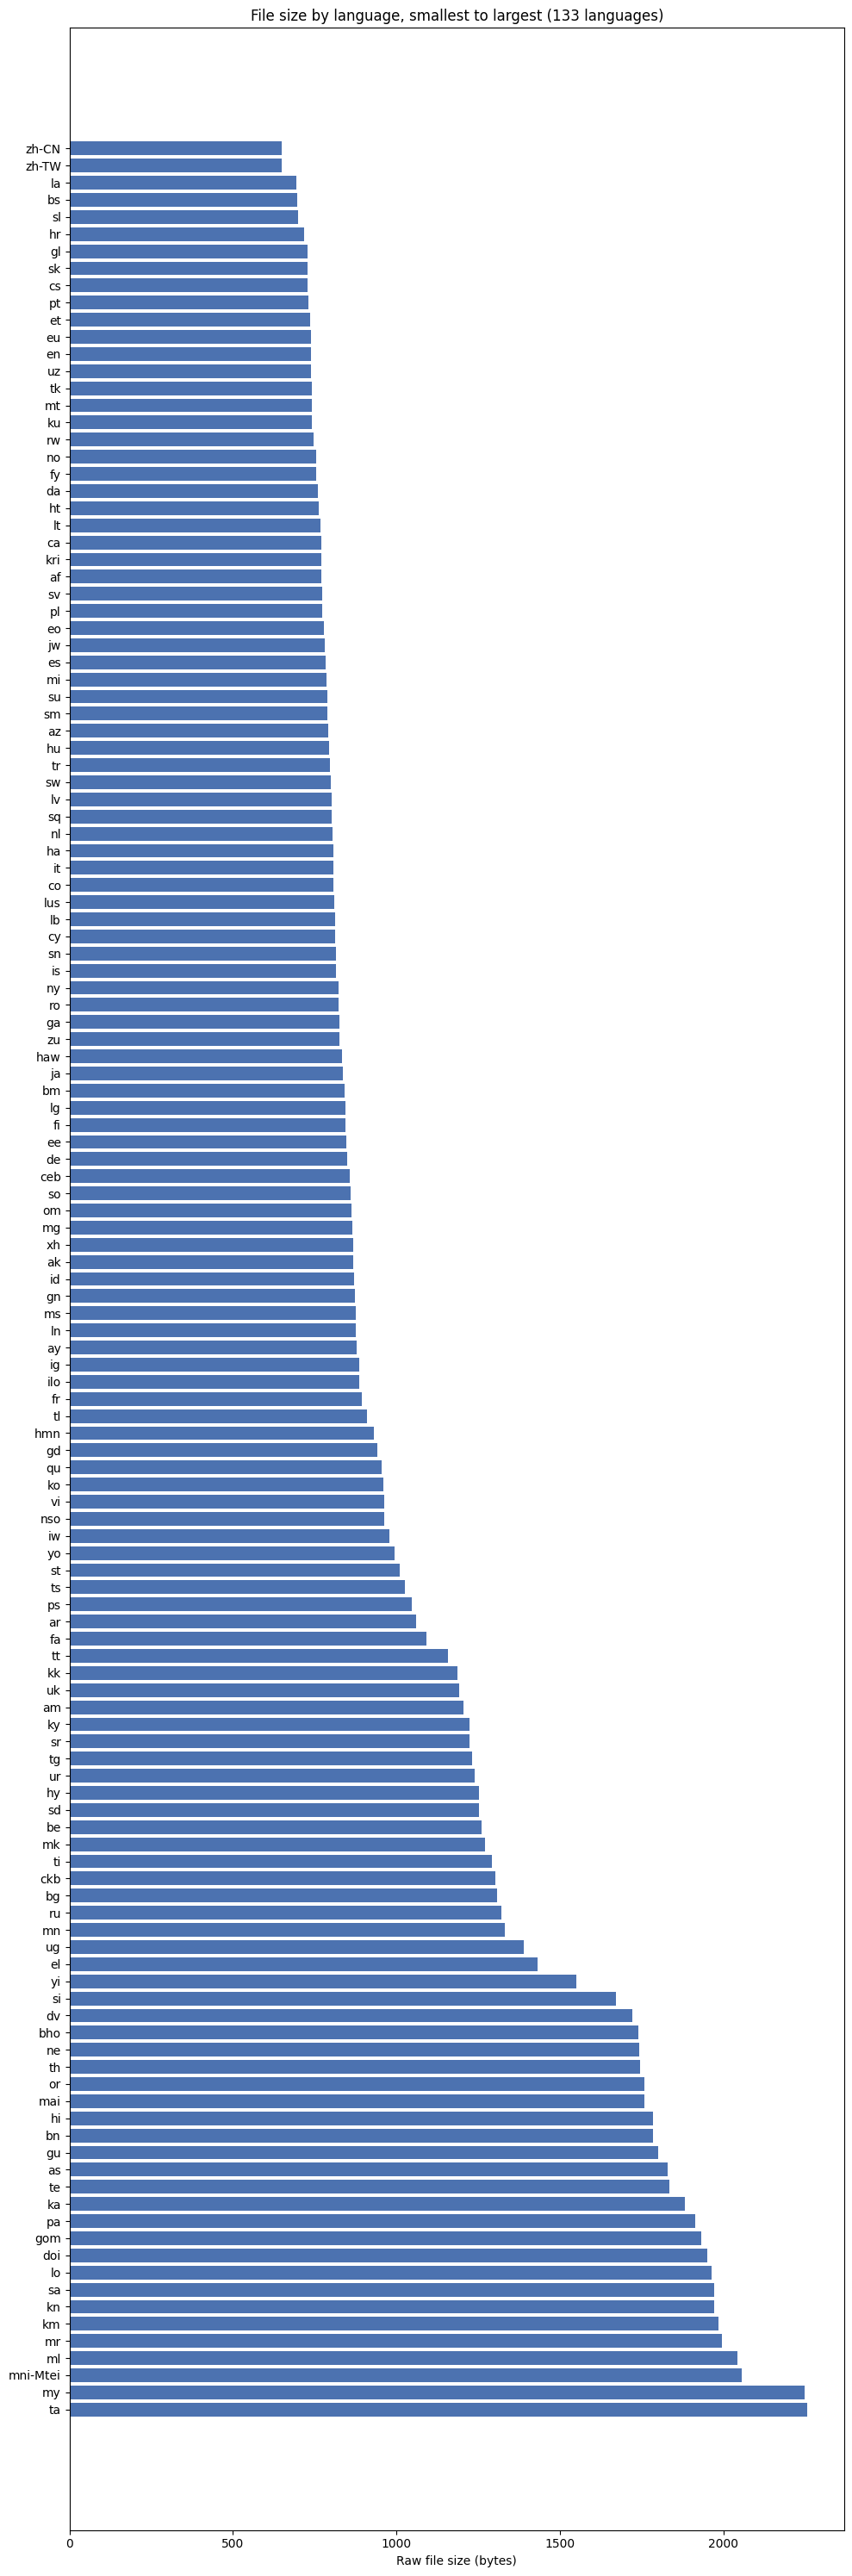

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 30))
ax.barh(df["language"], df["raw_size_bytes"], color="#4c72b0")
ax.set_xlabel("Raw file size (bytes)")
ax.set_title("File size by language, smallest to largest (133 languages)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("file_sizes_all.png", dpi=150)
plt.show()

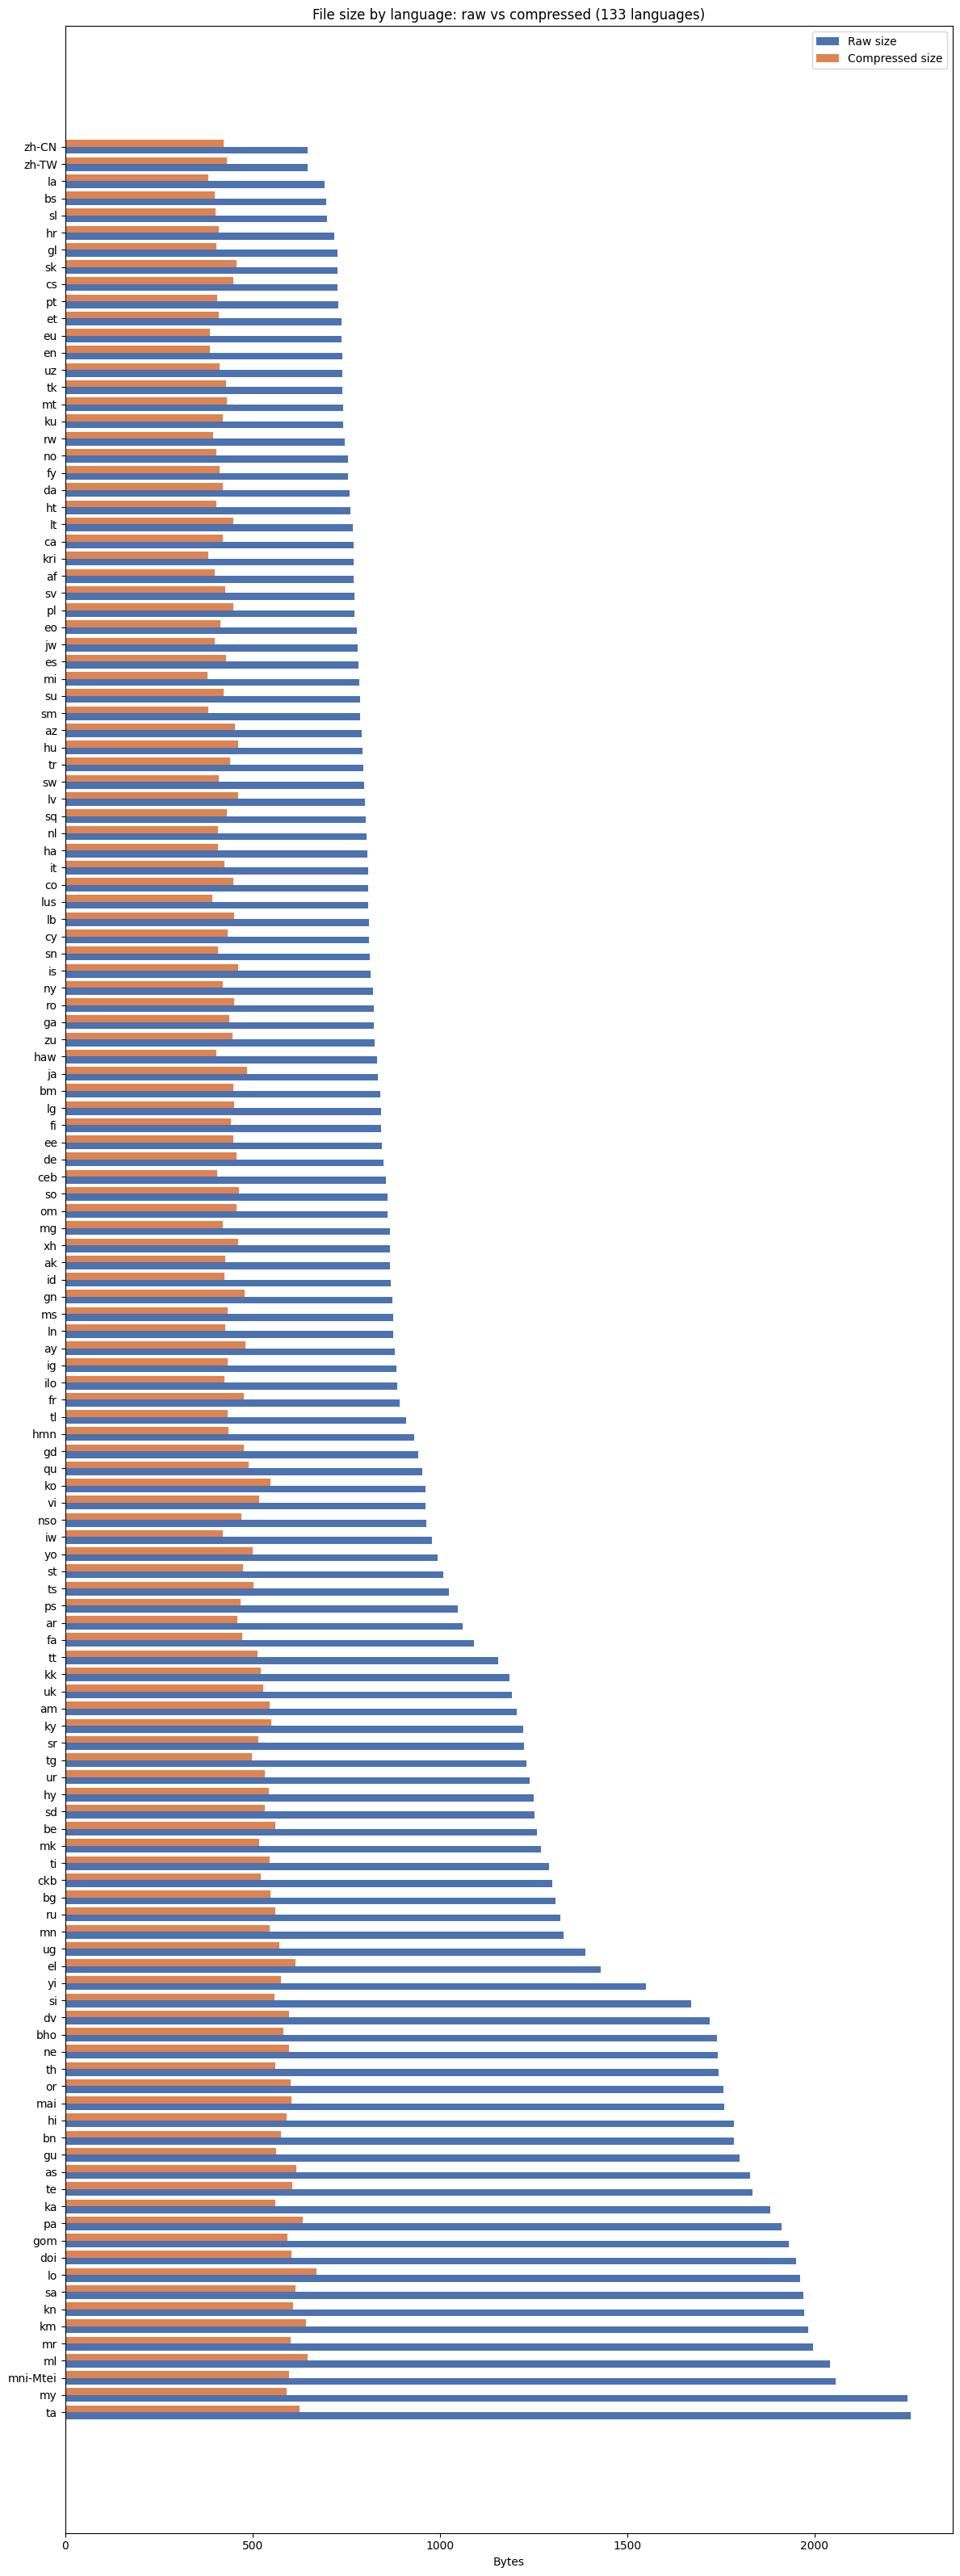

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 32))
y = range(len(df))
width = 0.4

ax.barh([i + width/2 for i in y], df["raw_size_bytes"], height=width, label="Raw size", color="#4c72b0")
ax.barh([i - width/2 for i in y], df["compressed_size_bytes"], height=width, label="Compressed size", color="#dd8452")

ax.set_yticks(list(y))
ax.set_yticklabels(df["language"])
ax.set_xlabel("Bytes")
ax.set_title("File size by language: raw vs compressed (133 languages)")
ax.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("file_sizes_comparison.png", dpi=150)
plt.show()

In [16]:
df.to_csv("sizes.csv", index=False)
print("Saved: sizes.csv, file_sizes_all.png, file_sizes_comparison.png")

Saved: sizes.csv, file_sizes_all.png, file_sizes_comparison.png


In [17]:
task2_section = """

## Task 2: File Size & Compression Measurement

For all 133 translated files, we measured:
1. **Raw size** — the exact byte size of the text file as saved (UTF-8 encoded)
2. **Compressed size** — the byte size after zlib compression (same family as ZIP)
3. **Compression ratio** — compressed ÷ raw (lower = more redundant/compressible text)

### Method
- Used Python's built-in `zlib` library, `zlib.compress(data, level=9)` for maximum compression
- Measured all 133 language files automatically via a loop, no manual work

### Key findings
- **Smallest raw files:** Chinese (Simplified & Traditional) — each character encodes a
  whole syllable/concept, needing far fewer characters than Latin-alphabet languages
- **Largest raw files:** Indic/Southeast Asian scripts (Tamil, Malayalam, Kannada, Khmer,
  Burmese) — multi-byte UTF-8 encoding plus more verbose grammar structures push these
  up to ~3x the size of Chinese for the same paragraph
- **Compression behavior varies by script:** Chinese text was already near its most
  compact form (raw ≈ compressed), while some Indic scripts showed less internal
  repetition to compress away despite their larger raw size

### Files
- `sizes.csv` — full results table (language, raw size, compressed size, ratio)
- `file_sizes_all.png` — bar chart of all 133 languages, raw size only
- `file_sizes_comparison.png` — bar chart comparing raw vs compressed size per language
"""

with open("README.md", "a", encoding="utf-8") as f:
    f.write(task2_section)

print("README updated")

README updated


In [19]:
!pwd
!ls

/content/Language-Efficiency-Analysis
file_sizes_all.png	   README.md  source
file_sizes_comparison.png  sizes.csv  translated


In [25]:
!git pull origin main --allow-unrelated-histories --no-rebase --no-edit

From https://github.com/Divyashukla-01/Language-Efficiency-Analysis
 * branch            main       -> FETCH_HEAD
Merge made by the 'ort' strategy.
 YSP_Task1_FullPipeline.ipynb | 664 +++++++++++++++++++++++++++++++++++++++++++
 1 file changed, 664 insertions(+)
 create mode 100644 YSP_Task1_FullPipeline.ipynb


In [26]:
!git push origin main

Enumerating objects: 12, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (8/8), 198.61 KiB | 9.46 MiB/s, done.
Total 8 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), done.
To https://github.com/Divyashukla-01/Language-Efficiency-Analysis.git
   d7e2ac6..06f1791  main -> main
